# Energie

De rots: asteroïde van ~2 km, dichtheid ~2500 kg/m³ → **m ≈ 10¹³ kg**.

Vraag 1: hoeveel energie kost het om dat ding met 1 g op snelheid te krijgen (piek 0.95 c)?

Vraag 2: volgens het boek is de brandstof de rots zelf — **vergruisd silicaatgesteente
(steenslak)**, door mass drivers naar buiten geslingerd; de zuurstof voor de bemanning is
een bijproduct van het malen. Hoe zwaar moet de rots zijn om daarmee 0.95 c te halen, en
hoe licht is de steen die overblijft?


## Formules

**1 · Kinetische energie**

$$E_k = (\gamma_\mathrm{piek} - 1)\,m\,c^2$$

- $E_k$ = bewegingsenergie op de piek (J)
- $m$ = massa van de rots (kg)
- $c$ = lichtsnelheid, 3·10⁸ m/s
- $\gamma_\mathrm{piek}$ = lorentzfactor op het omkeerpunt: $1 + gD/2 \approx 3.26$

Relativistische versie van ½mv². Bij $\gamma = 3.26$ is de bewegingsenergie 2.26× de
rustmassa-energie $mc^2$. En dit is één boostfase — de missie heeft er vier
(heen versnellen, heen remmen, terug ×2).

**2 · Raketvergelijking (relativistisch)**

$$\frac{M_0}{M_1} = \exp\!\left(\frac{c\,\mathrm{artanh}(\beta)}{v_e}\right)$$

- $M_0$ = massa bij vertrek (payload + alle steenslak), $M_1$ = massa op de piek (wat overblijft)
- $\beta$ = te halen eindsnelheid (fractie van c)
- $v_e$ = uitstroomsnelheid van de steenslak (m/s)
- $c\,\mathrm{artanh}(\beta)$ = de relativistische delta-v; voor 0.95 c is dat 1.85 c

Elke $v_e$ aan eindsnelheid kost een factor $e$ aan brandstof. De exponent is genadeloos:
0.95 c met steenslak van 30 km/s → exponent ~18 500 → massaverhouding $10^{8000}$.

**3 · Omgekeerd: wat haalt steenslak wél?**

$$\beta_\mathrm{max} = \tanh\!\left(\frac{v_e}{c}\,\ln\frac{M_0}{M_1}\right)$$

- zelfde symbolen; formule 2 opgelost naar $\beta$

Vul de massaverhouding in die je wél hebt en zie welke snelheid eruit komt.

**4 · Uitstroomlimiet van de brandstof zelf**

$$v_e^{\max} = \sqrt{\varepsilon\,(2-\varepsilon)}\;c \;\approx\; \sqrt{2\varepsilon}\,c$$

- $\varepsilon$ = fractie van de brandstofmassa die in energie wordt omgezet
  (kernsplijting 0.09%, D-T-fusie 0.38%, antimaterie 100%)

Een reactor ontkoppelt energie van reactiemassa — maar als de brandstof zelf ook de
uitlaat is, kan die uitlaat nooit sneller dan dit: alle vrijgemaakte energie in de
uitgestoten massa stoppen geeft precies deze snelheid.


In [1]:
import numpy as np

C = 3.0e8  # lichtsnelheid, m/s
g = 1.0323  # 1 g in lj/jr^2 (c = 1)
D = 4.37  # afstand Alpha Centauri, lj

GAMMA_PIEK = 1.0 + g * D / 2.0  # 3.26, zie snelheid.ipynb formule 3
BETA_PIEK = np.sqrt(1.0 - 1.0 / GAMMA_PIEK**2)  # 0.95


def kinetische_energie(m, gamma=GAMMA_PIEK):
    """Formule 1: E = (gamma - 1) * m * c^2, in joule."""
    return (gamma - 1.0) * m * C**2


def log10_massaverhouding(beta, v_e):
    """Formule 2: log10 van de benodigde M0/M1 (exp() zelf overflowt hier allang)."""
    return C * np.arctanh(beta) / v_e / np.log(10.0)


def haalbare_beta(verhouding, v_e):
    """Formule 3: maximale beta bij massaverhouding M0/M1 en uitstroomsnelheid v_e."""
    return np.tanh(v_e / C * np.log(verhouding))


def max_uitstroom(epsilon):
    """Formule 4: maximale uitstroomsnelheid (m/s) als de brandstof zelf de uitlaat is."""
    return np.sqrt(epsilon * (2.0 - epsilon)) * C

## Invullen: de energierekening

Rots van 10¹³ kg naar de piek duwen:


In [2]:
m_rots = 1e13  # kg
zon = 3.8e26  # W, totale lichtkracht van de zon
wereld = 6e20  # J/jaar, wereldenergieverbruik

E = kinetische_energie(m_rots)
sec_naar_piek = 3.0 * 365.25 * 86400  # 3 jaar aardtijd tot het omkeerpunt

print(f"Energie naar de piek:  {E:.1e} J   (x 4 boostfases voor de hele missie)")
print(f"  = {E / zon / 3600:.1f} uur TOTALE output van de zon")
print(f"  = {E / wereld:.1e} jaar wereldenergieverbruik")
print(f"Gemiddeld vermogen:    {E / sec_naar_piek:.1e} W  (wereld: ~2e13 W)")

Energie naar de piek:  2.0e+30 J   (x 4 boostfases voor de hele missie)
  = 1.5 uur TOTALE output van de zon
  = 3.4e+09 jaar wereldenergieverbruik
Gemiddeld vermogen:    2.1e+22 W  (wereld: ~2e13 W)


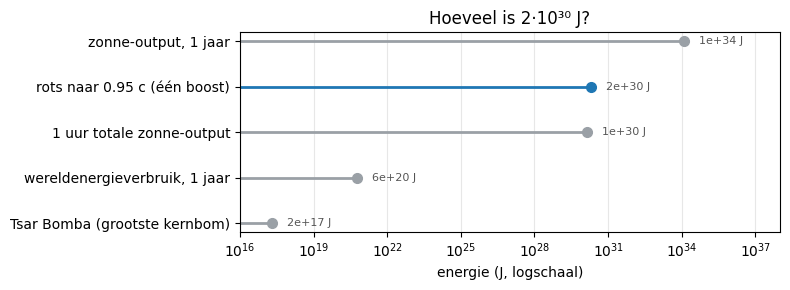

In [3]:
import matplotlib.pyplot as plt

GRIJS, BLAUW = "#9aa0a6", "#1f77b4"
schaal = [
    ("Tsar Bomba (grootste kernbom)", 2.1e17, GRIJS),
    ("wereldenergieverbruik, 1 jaar", wereld, GRIJS),
    ("1 uur totale zonne-output", zon * 3600, GRIJS),
    ("rots naar 0.95 c (één boost)", E, BLAUW),
    ("zonne-output, 1 jaar", zon * 3.156e7, GRIJS),
]

fig, ax = plt.subplots(figsize=(8, 3))
for y, (_naam, joule, kleur) in enumerate(schaal):
    ax.hlines(y, 1e16, joule, color=kleur, lw=2)
    ax.plot(joule, y, "o", color=kleur, ms=7)
    ax.text(joule * 4, y, f"{joule:.0e} J", va="center", fontsize=8, color="#555555")
ax.set_yticks(range(len(schaal)), [naam for naam, *_ in schaal])
ax.set_xscale("log")
ax.set_xlim(1e16, 1e38)
ax.set_xlabel("energie (J, logschaal)")
ax.set_title("Hoeveel is 2·10³⁰ J?")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

## Steenslak als brandstof

Zoals het boek het beschrijft: de mass drivers (elektromagnetische katapulten) zitten al op
de rots — wildcatters gebruiken ze om asteroïden naar aardbanen te verplaatsen — en de
motoren worden gevoerd met steenslak uit de rots zelf. Realistisch haalt zo'n katapult
2–3 km/s; wees gul en gun hem **30 km/s**. "Feasible" = een payload van 10⁷ kg
(leefruimte + bemanning + systemen) komt met 0.95 c op de piek. Hoe zwaar moet de rots
dan bij vertrek zijn?


In [4]:
v_e = 30e3  # m/s, uitstroomsnelheid steenslak (gul)
payload = 1e7  # kg

log10_M = log10_massaverhouding(BETA_PIEK, v_e)
print(f"Benodigde massaverhouding M0/M1:  10^{log10_M:,.0f}")
print(f"Rotsmassa bij vertrek:            10^{log10_M + np.log10(payload):,.0f} kg")
print("Massa waarneembaar heelal:        10^53 kg")
print(f"-> elke denkbare rots is ~10^{log10_M + np.log10(payload) - 53:,.0f} kg 'te licht'")

Benodigde massaverhouding M0/M1:  10^8,030
Rotsmassa bij vertrek:            10^8,037 kg
Massa waarneembaar heelal:        10^53 kg
-> elke denkbare rots is ~10^7,984 kg 'te licht'


Of stel de vraag andersom: neem de hele rots van 10¹³ kg als brandstoftank en brand
tot 0.95 c. Hoe licht is de steen die dan nog over is — dus zónder het gewicht van de
opgebruikte brandstof?


In [5]:
m_rots = 1e13  # kg

log10_rest = np.log10(m_rots) - log10_M
print(f"Overgebleven steen op 0.95 c:  10^{log10_rest:,.0f} kg")
print("Massa van één elektron:        ~10^-30 kg")
print(
    f"-> de resterende steen zou 10^{-30 - log10_rest:,.0f} keer LICHTER moeten zijn dan een elektron"
)
print("Zo licht bestaat materie niet: de rots is op lang voordat je in de buurt van 0.95 c komt.")

Overgebleven steen op 0.95 c:  10^-8,017 kg
Massa van één elektron:        ~10^-30 kg
-> de resterende steen zou 10^7,987 keer LICHTER moeten zijn dan een elektron
Zo licht bestaat materie niet: de rots is op lang voordat je in de buurt van 0.95 c komt.


Realistischer: wat haal je wél met onze rots van 10¹³ kg (waarvan 10⁷ kg payload
en de rest steenslak)?


In [6]:
verhouding = m_rots / payload
beta = haalbare_beta(verhouding, v_e)

print(f"Massaverhouding:   {verhouding:.0e}")
print(f"Haalbare snelheid: {beta:.5f} c  =  {beta * C / 1000:,.0f} km/s")
print(f"Reisduur naar Alpha Centauri: ~{D / beta:,.0f} jaar")

v_e_nodig = C * np.arctanh(BETA_PIEK) / np.log(verhouding)
print(
    f"v_e nodig voor 0.95 c bij deze verhouding: {v_e_nodig / 1000:,.0f} km/s = {v_e_nodig / C:.2f} c"
)

Massaverhouding:   1e+06
Haalbare snelheid: 0.00138 c  =  414 km/s
Reisduur naar Alpha Centauri: ~3,163 jaar
v_e nodig voor 0.95 c bij deze verhouding: 40,152 km/s = 0.13 c


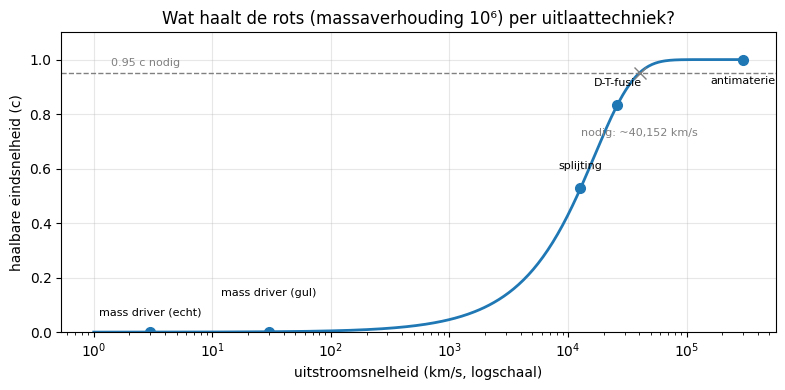

In [7]:
v = np.logspace(3, np.log10(C), 400)  # uitstroomsnelheid 1 km/s .. c, in m/s

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(v / 1000, haalbare_beta(verhouding, v), lw=2, color=BLAUW)
ax.axhline(BETA_PIEK, ls="--", lw=1, color="gray")
ax.text(1.4, BETA_PIEK + 0.025, "0.95 c nodig", fontsize=8, color="gray")

punten = [
    ("mass driver (echt)", 3e3, 0.06),
    ("mass driver (gul)", 30e3, 0.13),
    ("splijting", max_uitstroom(0.0009), 0.07),
    ("D-T-fusie", max_uitstroom(0.0038), 0.07),
    ("antimaterie", C, -0.09),
]
for naam, ve, offset in punten:
    bp = haalbare_beta(verhouding, ve)
    ax.plot(ve / 1000, bp, "o", ms=7, color=BLAUW)
    ax.annotate(naam, (ve / 1000, bp), (ve / 1000, bp + offset), fontsize=8, ha="center")

ve_nodig = C * np.arctanh(BETA_PIEK) / np.log(verhouding)
ax.plot(ve_nodig / 1000, BETA_PIEK, "x", ms=9, color="gray")
ax.annotate(
    f"nodig: ~{ve_nodig / 1000:,.0f} km/s",
    (ve_nodig / 1000, BETA_PIEK),
    (ve_nodig / 1000, 0.72),
    fontsize=8,
    ha="center",
    color="gray",
)

ax.set_xscale("log")
ax.set_ylim(0, 1.1)
ax.set_xlabel("uitstroomsnelheid (km/s, logschaal)")
ax.set_ylabel("haalbare eindsnelheid (c)")
ax.set_title("Wat haalt de rots (massaverhouding 10⁶) per uitlaattechniek?")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## En met een reactor aan boord?

Een reactor ontkoppelt energie van reactiemassa: de mass driver mag zo hard gooien als
het vermogen toelaat. Maar formule 2 blijft staan, en formule 4 begrenst hoe hard de
uitlaat kan als de brandstof zelf ook de uitlaat is. Per techniek, voor 0.95 c met
10⁷ kg payload:


In [8]:
brandstoffen = [
    ("kernsplijting", 0.0009),
    ("D-T-fusie", 0.0038),
    ("antimaterie", 1.0),
]
rapiditeit = np.arctanh(BETA_PIEK)

print("techniek        eps       v_e (km/s)   rots 1 boost    rots hele missie")
for naam, eps in brandstoffen:
    ve = max_uitstroom(eps)
    l10_boost = rapiditeit * C / ve / np.log(10.0)
    print(
        f"{naam:14}  {eps:7.4f}  {ve / 1000:>10,.0f}   10^{l10_boost + 7:>5.1f} kg     10^{4 * l10_boost + 7:>5.1f} kg"
    )

print()
print("Ter referentie: onze rots 10^13, aarde 10^24.8, zon 10^30.3, heelal 10^53 kg.")

techniek        eps       v_e (km/s)   rots 1 boost    rots hele missie
kernsplijting    0.0009      12,725   10^ 25.9 kg     10^ 82.7 kg
D-T-fusie        0.0038      26,129   10^ 16.2 kg     10^ 43.9 kg
antimaterie      1.0000     300,000   10^  7.8 kg     10^ 10.2 kg

Ter referentie: onze rots 10^13, aarde 10^24.8, zon 10^30.3, heelal 10^53 kg.


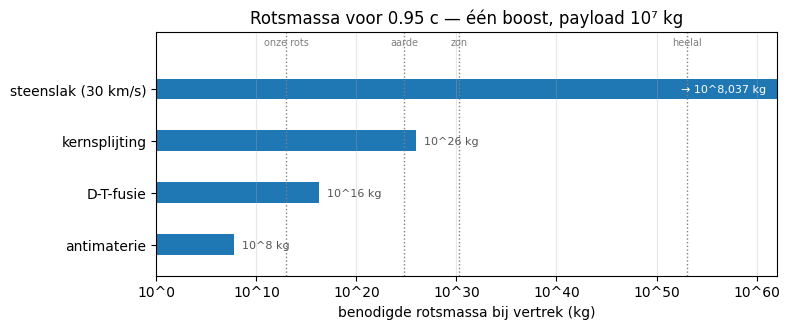

In [9]:
staven = [("steenslak (30 km/s)", log10_M + 7)]
for naam, eps in brandstoffen:
    staven.append((naam, rapiditeit * C / max_uitstroom(eps) / np.log(10.0) + 7))
staven.sort(key=lambda s: s[1])

referenties = [(13, "onze rots"), (24.8, "aarde"), (30.3, "zon"), (53, "heelal")]
MAX_X = 62

fig, ax = plt.subplots(figsize=(8, 3.4))
for y, (_naam, l10) in enumerate(staven):
    if l10 > MAX_X:  # steenslak: ver buiten elke schaal
        ax.barh(y, MAX_X, height=0.4, color=BLAUW)
        ax.text(
            MAX_X - 1, y, f"→ 10^{l10:,.0f} kg", va="center", ha="right", fontsize=8, color="white"
        )
    else:
        ax.barh(y, l10, height=0.4, color=BLAUW)
        ax.text(l10 + 0.8, y, f"10^{l10:.0f} kg", va="center", fontsize=8, color="#555555")
for x, naam in referenties:
    ax.axvline(x, ls=":", lw=1, color="gray")
    ax.text(x, len(staven) - 0.15, naam, fontsize=7, color="gray", ha="center")

ax.set_yticks(range(len(staven)), [naam for naam, _ in staven])
ax.set_xlim(0, MAX_X)
ax.set_ylim(-0.6, len(staven) + 0.1)
ax.set_xticks(range(0, MAX_X + 1, 10), [f"10^{x}" for x in range(0, MAX_X + 1, 10)])
ax.set_xlabel("benodigde rotsmassa bij vertrek (kg)")
ax.set_title("Rotsmassa voor 0.95 c — één boost, payload 10⁷ kg")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

Splijting: tien aardmassa's uranium per boost. Fusie: een brok van tientallen km — bijna
bespreekbaar, maar dan is de "rots" een berg deuterium (silicaat fuseert niet), en de
volledige missie (×4 boosts: exponenten tellen op) eist 10⁴⁴ kg — tientallen
Melkwegstelsels. Alleen antimaterie geeft een civiel getal.

En ook mét de perfecte uitlaat blijft het vermogen staan: 1 g op 10¹³ kg = 10¹⁴ N
stuwkracht; bij een fusie-uitlaat (0.09 c) is dat ~10²¹ W — vijftig miljoen keer het
wereldvermogen — en bij 99% efficiëntie nog 10¹⁹ W afvalwarmte, terwijl een gloeiende
rots van 2 km hooguit ~10¹² W kan wegstralen. De asteroïde verdampt zichzelf.


Samengevat: alleen de piek halen kost al ~2·10³⁰ J — anderhalf uur totale zonne-output,
miljarden jaren wereldenergieverbruik. En steenslak als brandstof maakt het pas echt stuk:
de raketvergelijking eist een rots van 10⁸⁰³⁷ kg, terwijl het hele heelal 10⁵³ kg weegt.
Brand je de rots van 10¹³ kg tóch op richting 0.95 c, dan moet de steen die overblijft
10⁻⁸⁰¹⁷ kg wegen — duizenden ordes lichter dan een elektron. Bestaat niet.

Een reactor helpt, maar redt het niet. De ladder per boost: steenslak 10⁸⁰³⁷ →
splijting 10²⁶ → fusie 10¹⁶ → antimaterie 10⁸ kg. Alleen die laatste trede is
wiskundig haalbaar — met technologie die niet bestaat — en het vermogen (10²¹ W)
en de afvalwarmte verdampen de rots hoe dan ook.

Wat steenslak wél kan: 10¹³ kg rots → 414 km/s → ~3200 jaar onderweg.
Generatieschip: prima. 0.95 c: nooit.
